In [5]:
import numpy as np
import pandas as pd
import statsmodels.api as sm
from statsmodels.tsa.stattools import coint
import itertools
import matplotlib.pyplot as plt
from scipy import stats
import os
import warnings

warnings.filterwarnings("ignore")

## Stage 1: Data Loading & Preparation


In [9]:
# Load cleaned price data
prices = pd.read_csv(
    "./dataset/cleaned_data.csv", parse_dates=["Date"], index_col="Date"
)

print(f"Price matrix shape: {prices.shape}")
print(f"\nDate range: {prices.index.min().date()} to {prices.index.max().date()}")
print(f"Number of tickers: {len(prices.columns)}")
print("\nFirst 5 rows:")
display(prices.head())

Price matrix shape: (3905, 432)

Date range: 2010-01-04 to 2024-12-20
Number of tickers: 432

First 5 rows:


,GNRC,CHTR,MTCH,NDAQ,WFC,WM,WELL,WMB,MU,NDSN,...,EXPE,EXPD,EXC,EW,EVRG,ETR,ETN,ESS,ES,IT
Date,,,,,,,,,,,,,,,,,,,,,
2010-01-04,12.84,35.0,5.856653,6.746667,27.320000,34.160000,44.040001,17.616472,10.85,31.530001,...,51.639999,35.080002,34.864479,7.289167,21.840000,41.075001,32.160000,82.620003,25.770000,18.700001
2010-01-05,12.84,35.0,5.985151,6.766667,28.070000,34.009998,44.660000,17.836576,11.17,31.490000,...,51.860001,35.320000,34.293865,7.341667,21.549999,40.419998,31.969999,83.120003,25.680000,18.730000
2010-01-06,12.84,35.0,5.936608,6.763333,28.110001,34.000000,44.439999,18.415367,11.22,31.139999,...,49.200001,34.500000,34.500713,7.422500,21.670000,40.625000,31.830000,83.699997,26.010000,18.860001
2010-01-07,12.84,35.0,5.965163,6.673333,29.129999,34.080002,44.529999,18.284937,10.84,31.514999,...,48.939999,34.290001,34.614838,7.490000,21.530001,40.139999,32.299999,84.570000,25.969999,20.440001
2010-01-08,12.84,33.5,6.002284,6.743333,28.860001,34.240002,44.070000,18.431671,11.10,31.875000,...,48.480000,34.650002,34.450787,7.456667,21.719999,39.755001,33.025002,83.699997,26.040001,20.660000


## Stage 1.2: Create Sector Mapping


In [10]:
# Get all ticker symbols
all_tickers = prices.columns.tolist()

# mapped tickers to sectors and selected a subset of 40 stocks (8 from each major sector) to keep the computation manageable
SECTOR_MAPPING = {
    # INFORMATION TECHNOLOGY
    "AAPL": "Information Technology",
    "MSFT": "Information Technology",
    "NVDA": "Information Technology",
    "ORCL": "Information Technology",
    "CSCO": "Information Technology",
    "CRM": "Information Technology",
    "ADBE": "Information Technology",
    "AVGO": "Information Technology",
    "INTC": "Information Technology",
    "AMD": "Information Technology",
    "AMAT": "Information Technology",
    "KLAC": "Information Technology",
    "LRCX": "Information Technology",
    "ANSS": "Information Technology",
    "CDNS": "Information Technology",
    "FTNT": "Information Technology",
    "ITW": "Information Technology",
    "ADSK": "Information Technology",
    "ADI": "Information Technology",
    "AKAM": "Information Technology",
    "APH": "Information Technology",
    "HPQ": "Information Technology",
    "IBM": "Information Technology",
    "INTU": "Information Technology",
    "JKHY": "Information Technology",
    "MSI": "Information Technology",
    "MU": "Information Technology",
    "MCHP": "Information Technology",
    "MPWR": "Information Technology",
    "NTAP": "Information Technology",
    "ON": "Information Technology",
    "PAYX": "Information Technology",
    "QCOM": "Information Technology",
    "SNPS": "Information Technology",
    "SMCI": "Information Technology",
    "SWKS": "Information Technology",
    "TDY": "Information Technology",
    "TEL": "Information Technology",
    "TER": "Information Technology",
    "TXN": "Information Technology",
    "TYL": "Information Technology",
    "VRSN": "Information Technology",
    "ZBRA": "Information Technology",
    "PTC": "Information Technology",
    "STE": "Information Technology",
    "STX": "Information Technology",
    "TRMB": "Information Technology",
    "NDSN": "Information Technology",
    # COMMUNICATION SERVICES
    "GOOGL": "Communication Services",
    "GOOG": "Communication Services",
    "META": "Communication Services",
    "NFLX": "Communication Services",
    "T": "Communication Services",
    "VZ": "Communication Services",
    "TMUS": "Communication Services",
    "CHTR": "Communication Services",
    "CMCSA": "Communication Services",
    "DIS": "Communication Services",
    "EA": "Communication Services",
    "TTWO": "Communication Services",
    "LYV": "Communication Services",
    "OMC": "Communication Services",
    "PARA": "Communication Services",
    "WBD": "Communication Services",
    "MTCH": "Communication Services",
    # CONSUMER DISCRETIONARY
    "AMZN": "Consumer Discretionary",
    "HD": "Consumer Discretionary",
    "LOW": "Consumer Discretionary",
    "MCD": "Consumer Discretionary",
    "SBUX": "Consumer Discretionary",
    "NKE": "Consumer Discretionary",
    "TJX": "Consumer Discretionary",
    "TGT": "Consumer Discretionary",
    "BKNG": "Consumer Discretionary",
    "YUM": "Consumer Discretionary",
    "LULU": "Consumer Discretionary",
    "ROST": "Consumer Discretionary",
    "ULTA": "Consumer Discretionary",
    "AZO": "Consumer Discretionary",
    "KMX": "Consumer Discretionary",
    "ORLY": "Consumer Discretionary",
    "GPC": "Consumer Discretionary",
    "BBY": "Consumer Discretionary",
    "BWA": "Consumer Discretionary",
    "CCL": "Consumer Discretionary",
    "DECK": "Consumer Discretionary",
    "DRI": "Consumer Discretionary",
    "DHI": "Consumer Discretionary",
    "DLTR": "Consumer Discretionary",
    "EXPE": "Consumer Discretionary",
    "HAS": "Consumer Discretionary",
    "LKQ": "Consumer Discretionary",
    "LEN": "Consumer Discretionary",
    "LVS": "Consumer Discretionary",
    "MGM": "Consumer Discretionary",
    "MAR": "Consumer Discretionary",
    "MAS": "Consumer Discretionary",
    "MHK": "Consumer Discretionary",
    "NVR": "Consumer Discretionary",
    "PHM": "Consumer Discretionary",
    "POOL": "Consumer Discretionary",
    "RL": "Consumer Discretionary",
    "RCL": "Consumer Discretionary",
    "TPR": "Consumer Discretionary",
    "TSCO": "Consumer Discretionary",
    "WYNN": "Consumer Discretionary",
    "CMG": "Consumer Discretionary",
    "EBAY": "Consumer Discretionary",
    "F": "Consumer Discretionary",
    "GRMN": "Consumer Discretionary",
    # CONSUMER STAPLES
    "KO": "Consumer Staples",
    "PEP": "Consumer Staples",
    "WMT": "Consumer Staples",
    "COST": "Consumer Staples",
    "PG": "Consumer Staples",
    "PM": "Consumer Staples",
    "MO": "Consumer Staples",
    "STZ": "Consumer Staples",
    "CL": "Consumer Staples",
    "CLX": "Consumer Staples",
    "KMB": "Consumer Staples",
    "CHD": "Consumer Staples",
    "CPB": "Consumer Staples",
    "CAG": "Consumer Staples",
    "HSY": "Consumer Staples",
    "HRL": "Consumer Staples",
    "SJM": "Consumer Staples",
    "MKC": "Consumer Staples",
    "TAP": "Consumer Staples",
    "TSN": "Consumer Staples",
    "K": "Consumer Staples",
    "KDP": "Consumer Staples",
    "MNST": "Consumer Staples",
    "WBA": "Consumer Staples",
    "KR": "Consumer Staples",
    "MDLZ": "Consumer Staples",
    "SYY": "Consumer Staples",
    "ADM": "Consumer Staples",
    "BF-B": "Consumer Staples",
    "EL": "Consumer Staples",
    "GIS": "Consumer Staples",
    "DG": "Consumer Staples",
    # ENERGY
    "XOM": "Energy",
    "CVX": "Energy",
    "COP": "Energy",
    "SLB": "Energy",
    "EOG": "Energy",
    "OXY": "Energy",
    "VLO": "Energy",
    "HES": "Energy",
    "DVN": "Energy",
    "CTRA": "Energy",
    "APA": "Energy",
    "OKE": "Energy",
    "WMB": "Energy",
    "BKR": "Energy",
    "EQT": "Energy",
    "FCX": "Energy",
    "TPL": "Energy",
    "MPC": "Energy",
    # FINANCIALS
    "JPM": "Financials",
    "BAC": "Financials",
    "WFC": "Financials",
    "GS": "Financials",
    "MS": "Financials",
    "C": "Financials",
    "BLK": "Financials",
    "SCHW": "Financials",
    "USB": "Financials",
    "PNC": "Financials",
    "TFC": "Financials",
    "COF": "Financials",
    "AIG": "Financials",
    "ALL": "Financials",
    "AFL": "Financials",
    "PRU": "Financials",
    "MET": "Financials",
    "TRV": "Financials",
    "HIG": "Financials",
    "BRK-B": "Financials",
    "CB": "Financials",
    "CINF": "Financials",
    "ACGL": "Financials",
    "AON": "Financials",
    "AJG": "Financials",
    "BRO": "Financials",
    "WRB": "Financials",
    "AIZ": "Financials",
    "BK": "Financials",
    "BEN": "Financials",
    "IVZ": "Financials",
    "TROW": "Financials",
    "NDAQ": "Financials",
    "CME": "Financials",
    "ICE": "Financials",
    "NTRS": "Financials",
    "STT": "Financials",
    "FITB": "Financials",
    "HBAN": "Financials",
    "KEY": "Financials",
    "MTB": "Financials",
    "RF": "Financials",
    "MCO": "Financials",
    "SPGI": "Financials",
    "MKTX": "Financials",
    "RJF": "Financials",
    "PFG": "Financials",
    "MSCI": "Financials",
    "CSGP": "Financials",
    "FICO": "Financials",
    "FI": "Financials",
    "ERIE": "Financials",
    "GL": "Financials",
    "GPN": "Financials",
    "WTW": "Financials",
    "L": "Financials",
    "MA": "Financials",
    "V": "Financials",
    "AMP": "Financials",
    "BX": "Financials",
    "DFS": "Financials",
    "EG": "Financials",
    "EFX": "Financials",
    "FIS": "Financials",
    "MMC": "Financials",
    "PGR": "Financials",
    "RVTY": "Financials",
    "VRSK": "Financials",
    # HEALTHCARE
    "JNJ": "Healthcare",
    "UNH": "Healthcare",
    "PFE": "Healthcare",
    "ABT": "Healthcare",
    "TMO": "Healthcare",
    "ABBV": "Healthcare",
    "MRK": "Healthcare",
    "AMGN": "Healthcare",
    "BMY": "Healthcare",
    "GILD": "Healthcare",
    "CI": "Healthcare",
    "CVS": "Healthcare",
    "HUM": "Healthcare",
    "ELV": "Healthcare",
    "CNC": "Healthcare",
    "MOH": "Healthcare",
    "DVA": "Healthcare",
    "UHS": "Healthcare",
    "CAH": "Healthcare",
    "MCK": "Healthcare",
    "ZBH": "Healthcare",
    "BAX": "Healthcare",
    "BDX": "Healthcare",
    "BSX": "Healthcare",
    "EW": "Healthcare",
    "HOLX": "Healthcare",
    "ISRG": "Healthcare",
    "IDXX": "Healthcare",
    "RMD": "Healthcare",
    "SYK": "Healthcare",
    "TECH": "Healthcare",
    "ZTS": "Healthcare",
    "ALGN": "Healthcare",
    "BIIB": "Healthcare",
    "DXCM": "Healthcare",
    "INCY": "Healthcare",
    "IFF": "Healthcare",
    "REGN": "Healthcare",
    "VRTX": "Healthcare",
    "A": "Healthcare",
    "LH": "Healthcare",
    "DGX": "Healthcare",
    "HSIC": "Healthcare",
    "LLY": "Healthcare",
    "WST": "Healthcare",
    "MDT": "Healthcare",
    "COO": "Healthcare",
    "CRL": "Healthcare",
    "DHR": "Healthcare",
    "PODD": "Healthcare",
    "VTRS": "Healthcare",
    "HCA": "Healthcare",
    # INDUSTRIALS
    "BA": "Industrials",
    "CAT": "Industrials",
    "DE": "Industrials",
    "GE": "Industrials",
    "HON": "Industrials",
    "RTX": "Industrials",
    "LMT": "Industrials",
    "NOC": "Industrials",
    "GD": "Industrials",
    "TXT": "Industrials",
    "TDG": "Industrials",
    "AME": "Industrials",
    "EMR": "Industrials",
    "ETN": "Industrials",
    "ROK": "Industrials",
    "ITW": "Industrials",
    "PH": "Industrials",
    "CMI": "Industrials",
    "PCAR": "Industrials",
    "UAL": "Industrials",
    "DAL": "Industrials",
    "LUV": "Industrials",
    "FDX": "Industrials",
    "UPS": "Industrials",
    "ODFL": "Industrials",
    "JBHT": "Industrials",
    "CHRW": "Industrials",
    "EXPD": "Industrials",
    "FAST": "Industrials",
    "GWW": "Industrials",
    "CSX": "Industrials",
    "NSC": "Industrials",
    "UNP": "Industrials",
    "CPRT": "Industrials",
    "URI": "Industrials",
    "AOS": "Industrials",
    "DOV": "Industrials",
    "ROL": "Industrials",
    "TT": "Industrials",
    "PWR": "Industrials",
    "VMC": "Industrials",
    "WAB": "Industrials",
    "WAT": "Industrials",
    "GNRC": "Industrials",
    "WM": "Industrials",
    "RSG": "Industrials",
    "SNA": "Industrials",
    "SWK": "Industrials",
    "TFX": "Industrials",
    "BLDR": "Industrials",
    "BR": "Industrials",
    "CTAS": "Industrials",
    "GEN": "Industrials",
    "HUBB": "Industrials",
    "IEX": "Industrials",
    "JCI": "Industrials",
    "JBL": "Industrials",
    "LDOS": "Industrials",
    "LHX": "Industrials",
    "MTD": "Industrials",
    "PNR": "Industrials",
    "ROP": "Industrials",
    "IT": "Industrials",
    "TYC": "Industrials",
    # MATERIALS
    "LIN": "Materials",
    "APD": "Materials",
    "SHW": "Materials",
    "ECL": "Materials",
    "DD": "Materials",
    "FCX": "Materials",
    "NUE": "Materials",
    "STLD": "Materials",
    "CF": "Materials",
    "MOS": "Materials",
    "FMC": "Materials",
    "PPG": "Materials",
    "CE": "Materials",
    "ALB": "Materials",
    "AVY": "Materials",
    "BALL": "Materials",
    "PKG": "Materials",
    "MLM": "Materials",
    "NEM": "Materials",
    "IP": "Materials",
    "EMN": "Materials",
    "VMC": "Materials",
    "DOW": "Materials",
    # REAL ESTATE
    "AMT": "Real Estate",
    "PLD": "Real Estate",
    "EQIX": "Real Estate",
    "PSA": "Real Estate",
    "WELL": "Real Estate",
    "SPG": "Real Estate",
    "EXR": "Real Estate",
    "EQR": "Real Estate",
    "AVB": "Real Estate",
    "ESS": "Real Estate",
    "UDR": "Real Estate",
    "MAA": "Real Estate",
    "CPT": "Real Estate",
    "CBRE": "Real Estate",
    "DLR": "Real Estate",
    "REG": "Real Estate",
    "VTR": "Real Estate",
    "KIM": "Real Estate",
    "IRM": "Real Estate",
    "ARE": "Real Estate",
    "BXP": "Real Estate",
    "HST": "Real Estate",
    "CCI": "Real Estate",
    "SBAC": "Real Estate",
    "DOC": "Real Estate",
    "O": "Real Estate",
    "WY": "Real Estate",
    "COR": "Real Estate",
    "FRT": "Real Estate",
    # UTILITIES
    "NEE": "Utilities",
    "DUK": "Utilities",
    "SO": "Utilities",
    "SRE": "Utilities",
    "AEP": "Utilities",
    "EXC": "Utilities",
    "XEL": "Utilities",
    "WEC": "Utilities",
    "ES": "Utilities",
    "ETR": "Utilities",
    "EVRG": "Utilities",
    "FE": "Utilities",
    "NI": "Utilities",
    "PNW": "Utilities",
    "PPL": "Utilities",
    "AEE": "Utilities",
    "ATO": "Utilities",
    "CMS": "Utilities",
    "CNP": "Utilities",
    "ED": "Utilities",
    "EIX": "Utilities",
    "LNT": "Utilities",
    "NRG": "Utilities",
    "PCG": "Utilities",
    "PEG": "Utilities",
    "D": "Utilities",
    "DTE": "Utilities",
    "AWK": "Utilities",
    "AES": "Utilities",
}

# Create sector dataframe
sector_df = pd.DataFrame(
    {
        "Symbol": all_tickers,
        "Sector": [SECTOR_MAPPING.get(ticker, "Unknown") for ticker in all_tickers],
    }
)

mapped_count = (sector_df["Sector"] != "Unknown").sum()
print(f"Mapped {mapped_count}/{len(all_tickers)} tickers to sectors")
print(f"{len(all_tickers) - mapped_count} tickers need manual mapping\n")

print("Sector Distribution:")
print(sector_df["Sector"].value_counts().sort_values(ascending=False))

# Save to CSV
output_path = "./dataset/stock_sectors.csv"
sector_df.to_csv(output_path, index=False)
print(f"Saved sector mapping to: {output_path}")

stock_sectors = dict(zip(sector_df["Symbol"], sector_df["Sector"]))
display(sector_df.head(10))

Mapped 415/432 tickers to sectors
17 tickers need manual mapping

Sector Distribution:
Sector
Financials                68
Industrials               62
Healthcare                49
Information Technology    47
Consumer Discretionary    45
Consumer Staples          32
Real Estate               29
Utilities                 29
Materials                 22
Unknown                   17
Communication Services    16
Energy                    16
Name: count, dtype: int64
Saved sector mapping to: ./dataset/stock_sectors.csv


,Symbol,Sector
0,GNRC,Industrials
1,CHTR,Communication Services
2,MTCH,Communication Services
3,NDAQ,Financials
4,WFC,Financials
5,WM,Industrials
6,WELL,Real Estate
7,WMB,Energy
8,MU,Information Technology
9,NDSN,Information Technology


## Stage 1.3: Select Stocks for Analysis


In [11]:
# Load sector mapping
if os.path.exists("./dataset/stock_sectors.csv"):
    sector_df = pd.read_csv("./dataset/stock_sectors.csv")
    stock_sectors = dict(zip(sector_df["Symbol"], sector_df["Sector"]))

# Select stocks from major sectors
target_sectors = [
    "Financials",
    "Consumer Staples",
    "Healthcare",
    "Industrials",
    "Information Technology",
]

selected_tickers = []
stocks_per_sector = 8

for sector in target_sectors:
    stocks_in_sector = [
        ticker
        for ticker, sec in stock_sectors.items()
        if sec == sector and ticker in prices.columns
    ]
    missing_counts = prices[stocks_in_sector].isna().sum().sort_values()
    selected_tickers.extend(missing_counts.head(stocks_per_sector).index.tolist())
    if len(selected_tickers) >= 40:
        break

selected_tickers = selected_tickers[:40]
prices_subset = prices[selected_tickers].copy()

selected_sectors = [stock_sectors.get(t, "Unknown") for t in selected_tickers]
sector_counts = pd.Series(selected_sectors).value_counts()

print(f"Selected {len(selected_tickers)} stocks for pairs trading")
print(
    f"This will test {len(list(itertools.combinations(selected_tickers, 2)))} pairs\n"
)
print("Sector breakdown of selected stocks:")
for sector, count in sector_counts.items():
    print(f"  {sector}: {count} stocks")

print(f"\nSelected tickers: {sorted(selected_tickers)}")

Selected 40 stocks for pairs trading
This will test 780 pairs

Sector breakdown of selected stocks:
  Financials: 8 stocks
  Consumer Staples: 8 stocks
  Healthcare: 8 stocks
  Industrials: 8 stocks
  Information Technology: 8 stocks

Selected tickers: ['ABT', 'ADM', 'AJG', 'ALGN', 'ALL', 'AMAT', 'AMD', 'AMGN', 'AMP', 'BDX', 'BF-B', 'BIIB', 'BLK', 'BMY', 'BR', 'CDNS', 'CME', 'CMI', 'CNC', 'COF', 'CPRT', 'CRM', 'CSCO', 'CSGP', 'CSX', 'CTAS', 'DAL', 'DE', 'GIS', 'GNRC', 'HRL', 'HSY', 'KDP', 'KMB', 'MRK', 'MU', 'NDAQ', 'PTC', 'QCOM', 'WMT']


## Stage 2: Cointegration Testing (Engle-Granger)


In [ ]:
from pathos.multiprocessing import ProcessingPool as Pool
from tqdm import tqdm

tickers = selected_tickers
pairs = list(itertools.combinations(tickers, 2))

print(f"Testing {len(pairs)} pairs from {len(tickers)} stocks...\n")


# run cointegration test
def run_coint(pair):
    try:
        a, b = pair
        s1 = prices_subset[a].dropna()
        s2 = prices_subset[b].dropna()

        if len(s1) < 100 or len(s2) < 100:
            return (pair, np.nan)

        # Align on common dates
        common_dates = s1.index.intersection(s2.index)
        if len(common_dates) < 100:
            return (pair, np.nan)

        s1_aligned = s1.loc[common_dates]
        s2_aligned = s2.loc[common_dates]

        _, pvalue, _ = coint(s1_aligned, s2_aligned)
        return (pair, pvalue)
    except Exception as e:
        return (pair, np.nan)


# parallel processing to speed up cointegration tests
n_processes = 4
pool = Pool(n_processes)

results = []
try:
    for res in tqdm(
        pool.imap(run_coint, pairs), total=len(pairs), desc="Cointegration tests"
    ):
        results.append(res)
except KeyboardInterrupt:
    print("\nInterrupted by user. Saving partial results...")
finally:
    pool.close()
    pool.join()

coint_results = pd.DataFrame(results, columns=["pair", "pvalue"])
coint_results = coint_results.dropna(subset=["pvalue"]).sort_values("pvalue")

print(f"\nCompleted {len(coint_results)}/{len(pairs)} tests successfully")
print(f"\nSummary:")
print(f"  Total pairs tested: {len(pairs)}")
print(f"  Successful tests: {len(coint_results)}")
print(f"  Failed tests: {len(pairs) - len(coint_results)}")
print(
    f"  Pairs with p-value < 0.05: {len(coint_results[coint_results['pvalue'] < 0.05])}"
)
print(
    f"  Pairs with p-value < 0.01: {len(coint_results[coint_results['pvalue'] < 0.01])}"
)

# Save results
coint_results.to_csv("./dataset/cointegration_results.csv", index=False)
print(f"\nResults saved to: ./dataset/cointegration_results.csv")

print(f"\nTop 10 most cointegrated pairs:")
display(coint_results.head(10))

Testing 780 pairs from 40 stocks...



Cointegration tests: 100%|██████████| 780/780 [2:06:17<00:00,  9.72s/it]  


Completed 780/780 tests successfully

Summary:
  Total pairs tested: 780
  Successful tests: 780
  Failed tests: 0
  Pairs with p-value < 0.05: 51
  Pairs with p-value < 0.01: 18

Results saved to: ./dataset/cointegration_results.csv

Top 10 most cointegrated pairs:


,pair,pvalue
279,"(AJG, CDNS)",0.000035
73,"(CME, CSCO)",0.000055
756,"(MU, CRM)",0.000156
694,"(CMI, MU)",0.001473
681,"(BR, MU)",0.002029
301,"(WMT, CMI)",0.003729
779,"(AMD, AMAT)",0.003966
177,"(BLK, MU)",0.005147
753,"(MU, PTC)",0.005709
95,"(CSGP, ABT)",0.006102


## Stage 2.2: Analyze Cointegration by Sector


In [16]:
import ast
import os

# Load stock_sectors from CSV if available, otherwise fall back to existing in-memory mapping
stock_sectors_path = "./dataset/stock_sectors.csv"
if os.path.exists(stock_sectors_path):
    sector_df = pd.read_csv(stock_sectors_path)
    stock_sectors = dict(zip(sector_df["Symbol"], sector_df["Sector"]))
    print(f"Loaded stock_sectors from: {stock_sectors_path}")
else:
    try:
        stock_sectors  # use existing variable if present
        print("Using in-memory stock_sectors mapping")
    except NameError:
        stock_sectors = {}
        print(
            "stock_sectors CSV not found and no in-memory mapping available. Using empty mapping."
        )

# Load cointegration results from CSV if available, otherwise use in-memory coint_results
if os.path.exists(coint_path):
    coint_results = pd.read_csv(coint_path)
    print(f"Loaded cointegration results from: {coint_path}")
else:
    print(
        "Cointegration results CSV not found, using in-memory coint_results (if available)."
    )

# Ensure pvalue is numeric
if "pvalue" in coint_results.columns:
    coint_results["pvalue"] = pd.to_numeric(coint_results["pvalue"], errors="coerce")

# Parse 'pair' column to tuple if it's stored as a string
if "pair" in coint_results.columns and coint_results["pair"].dtype == object:

    def _parse_pair(x):
        try:
            return tuple(ast.literal_eval(x))
        except Exception:
            s = str(x).strip().strip("()[]")
            parts = [p.strip(" '\"") for p in s.split(",") if p.strip()]
            return (parts[0], parts[1]) if len(parts) >= 2 else (None, None)

    coint_results["pair"] = coint_results["pair"].apply(_parse_pair)

# Proceed with sector analysis using the loaded coint_results
# Filter highly cointegrated pairs (p-value < 0.01)
highly_cointegrated = coint_results[coint_results["pvalue"] < 0.01].copy()

print(
    f"Analyzing {len(highly_cointegrated)} highly cointegrated pairs (p-value < 0.01)\n"
)

# Extract sectors for each pair
pair_analysis = []
for idx, row in highly_cointegrated.iterrows():
    pair = row["pair"]
    if not pair or pair[0] is None:
        continue
    ticker1, ticker2 = pair
    sector1 = stock_sectors.get(ticker1, "Unknown")
    sector2 = stock_sectors.get(ticker2, "Unknown")
    same_sector = sector1 == sector2
    pair_analysis.append(
        {
            "Ticker1": ticker1,
            "Sector1": sector1,
            "Ticker2": ticker2,
            "Sector2": sector2,
            "Same_Sector": same_sector,
            "pvalue": row["pvalue"],
        }
    )

pair_df = pd.DataFrame(pair_analysis).sort_values("pvalue")

print("\nHighly Cointegrated Pairs (p-value < 0.01):")
for idx, row in pair_df.iterrows():
    same_sector_marker = "✓" if row["Same_Sector"] else "✗"
    print(
        f"\n{same_sector_marker} {row['Ticker1']:6s} ({row['Sector1']:25s})  ↔  {row['Ticker2']:6s} ({row['Sector2']:25s})"
    )
    print(f"   p-value: {row['pvalue']:.6f}")


same_sector_count = int(pair_df["Same_Sector"].sum()) if len(pair_df) > 0 else 0
cross_sector_count = len(pair_df) - same_sector_count
same_sector_pct = (same_sector_count / len(pair_df)) * 100 if len(pair_df) > 0 else 0

print(f"\nSECTOR ANALYSIS STATISTICS:")
print(f"  Total highly cointegrated pairs: {len(pair_df)}")
print(f"  Same-sector pairs: {same_sector_count} ({same_sector_pct:.1f}%)")
print(f"  Cross-sector pairs: {cross_sector_count} ({100 - same_sector_pct:.1f}%)")

if len(pair_df) > 0:
    print(f"\nComplete DataFrame:")
    display(pair_df)

Loaded stock_sectors from: ./dataset/stock_sectors.csv
Loaded cointegration results from: ./dataset/cointegration_results.csv
Analyzing 18 highly cointegrated pairs (p-value < 0.01)


Highly Cointegrated Pairs (p-value < 0.01):

✗ AJG    (Financials               )  ↔  CDNS   (Information Technology   )
   p-value: 0.000035

✗ CME    (Financials               )  ↔  CSCO   (Information Technology   )
   p-value: 0.000055

✓ MU     (Information Technology   )  ↔  CRM    (Information Technology   )
   p-value: 0.000156

✗ CMI    (Industrials              )  ↔  MU     (Information Technology   )
   p-value: 0.001473

✗ BR     (Industrials              )  ↔  MU     (Information Technology   )
   p-value: 0.002029

✗ WMT    (Consumer Staples         )  ↔  CMI    (Industrials              )
   p-value: 0.003729

✓ AMD    (Information Technology   )  ↔  AMAT   (Information Technology   )
   p-value: 0.003966

✗ BLK    (Financials               )  ↔  MU     (Information Technology   )
   p-valu

,Ticker1,Sector1,Ticker2,Sector2,Same_Sector,pvalue
0,AJG,Financials,CDNS,Information Technology,False,0.000035
1,CME,Financials,CSCO,Information Technology,False,0.000055
2,MU,Information Technology,CRM,Information Technology,True,0.000156
3,CMI,Industrials,MU,Information Technology,False,0.001473
4,BR,Industrials,MU,Information Technology,False,0.002029
5,WMT,Consumer Staples,CMI,Industrials,False,0.003729
6,AMD,Information Technology,AMAT,Information Technology,True,0.003966
7,BLK,Financials,MU,Information Technology,False,0.005147
8,MU,Information Technology,PTC,Information Technology,True,0.005709
9,CSGP,Financials,ABT,Healthcare,False,0.006102


In [18]:
len(coint_results[coint_results["pvalue"] < 0.05])

51

## Stage 3: Baseline Cointegration Strategy - Spread & Z-Score


In [ ]:
# Select top cointegrated pairs for backtesting
backtest_pairs = coint_results[coint_results["pvalue"] < 0.05].head(10).copy()

print(f"Selected {len(backtest_pairs)} pairs for backtesting")


def compute_spread_and_zscore(ticker1, ticker2, prices_df, window=20):
    
    # Compute spread and z-score for a cointegrated pair.
    # Spread = Price1 - Beta * Price2 - Alpha
    # Z-Score = (Spread - Mean(Spread)) / Std(Spread)
    
    s1 = prices_df[ticker1].dropna()
    s2 = prices_df[ticker2].dropna()

    # Align to common dates
    common_dates = s1.index.intersection(s2.index)
    s1 = s1.loc[common_dates]
    s2 = s2.loc[common_dates]

    # Estimate hedge ratio using OLS
    X = sm.add_constant(s2)
    model = sm.OLS(s1, X).fit()
    beta = model.params[s2.name]
    alpha = model.params["const"]

    # Compute spread
    spread = s1 - beta * s2 - alpha

    # Compute rolling mean and std
    spread_mean = spread.rolling(window=window).mean()
    spread_std = spread.rolling(window=window).std()

    # Compute z-score
    zscore = (spread - spread_mean) / spread_std

    return {
        "spread": spread,
        "zscore": zscore,
        "spread_mean": spread_mean,
        "spread_std": spread_std,
        "beta": beta,
        "alpha": alpha,
    }


# Compute metrics for each pair
spread_metrics = {}
for idx, row in backtest_pairs.iterrows():
    ticker1, ticker2 = row["pair"]
    metrics = compute_spread_and_zscore(ticker1, ticker2, prices_subset)
    spread_metrics[(ticker1, ticker2)] = metrics
    print(f"\n{ticker1} ↔ {ticker2} (p={row['pvalue']:.6f})")
    print(f"  Beta (hedge ratio): {metrics['beta']:.4f}, Alpha: {metrics['alpha']:.4f}")

print(f"\nSpread and z-score computed for all backtest pairs")

Selected 10 pairs for backtesting

AJG ↔ CDNS (p=0.000035)
  Beta (hedge ratio): 0.8218, Alpha: 28.4429

CME ↔ CSCO (p=0.000055)
  Beta (hedge ratio): 4.5471, Alpha: -29.5652

MU ↔ CRM (p=0.000156)
  Beta (hedge ratio): 0.3329, Alpha: -0.8536

CMI ↔ MU (p=0.001473)
  Beta (hedge ratio): 1.9221, Alpha: 85.7988

BR ↔ MU (p=0.002029)
  Beta (hedge ratio): 1.8923, Alpha: 16.2201

WMT ↔ CMI (p=0.003729)
  Beta (hedge ratio): 0.2242, Alpha: -2.5853

AMD ↔ AMAT (p=0.003966)
  Beta (hedge ratio): 0.8562, Alpha: -9.7533

BLK ↔ MU (p=0.005147)
  Beta (hedge ratio): 7.1402, Alpha: 172.6915

MU ↔ PTC (p=0.005709)
  Beta (hedge ratio): 0.5755, Alpha: -1.3168

CSGP ↔ ABT (p=0.006102)
  Beta (hedge ratio): 0.8498, Alpha: -16.1183

Spread and z-score computed for all backtest pairs


## Stage 3.2: Mean-Reversion Trading Rule & Backtesting


In [ ]:
def backtest_pair(
    ticker1, ticker2, prices_df, metrics, entry_zscore=2.0, exit_zscore=0.0
):
    spread = metrics["spread"]
    zscore = metrics["zscore"]
    beta = metrics["beta"]

    # Filter out NaN values
    valid_idx = zscore.notna()
    zscore_clean = zscore[valid_idx]

    # Initialize tracking
    positions = []
    in_position = False
    entry_date = None
    entry_zscore_val = None
    entry_price1 = None
    entry_price2 = None

    prices1 = prices_df[ticker1]
    prices2 = prices_df[ticker2]

    for date in zscore_clean.index:
        z = zscore_clean.loc[date]
        p1 = prices1.loc[date]
        p2 = prices2.loc[date]

        if pd.isna(p1) or pd.isna(p2) or pd.isna(z):
            continue

        if not in_position:
            # Entry: z-score > entry_zscore
            if z > entry_zscore:
                in_position = True
                entry_date = date
                entry_zscore_val = z
                entry_price1 = p1
                entry_price2 = p2

        else:
            # Exit: z-score < exit_zscore
            if z < exit_zscore:
                exit_date = date
                exit_zscore_val = z
                exit_price1 = p1
                exit_price2 = p2

                # PnL = (entry_p1 - exit_p1) - beta * (entry_p2 - exit_p2)
                pnl = (entry_price1 - exit_price1) - beta * (entry_price2 - exit_price2)

                positions.append(
                    {
                        "entry_date": entry_date,
                        "entry_zscore": entry_zscore_val,
                        "exit_date": exit_date,
                        "exit_zscore": exit_zscore_val,
                        "pnl": pnl,
                        "days_held": (exit_date - entry_date).days,
                    }
                )

                in_position = False

    return pd.DataFrame(positions)


# Backtest all pairs
backtest_results = {}
for ticker1, ticker2 in spread_metrics.keys():
    results_df = backtest_pair(
        ticker1, ticker2, prices_subset, spread_metrics[(ticker1, ticker2)]
    )
    if len(results_df) > 0:
        backtest_results[(ticker1, ticker2)] = results_df

print(f"Backtesting complete. Generated {len(backtest_results)} pairs with trades.")

if backtest_results:
    first_pair = list(backtest_results.keys())[0]
    print(f"\nExample: {first_pair[0]} ↔ {first_pair[1]}")
    print(f"Total trades: {len(backtest_results[first_pair])}")
    print(f"\nFirst 5 trades:")
    display(backtest_results[first_pair].head())

Backtesting complete. Generated 10 pairs with trades.

Example: AJG ↔ CDNS
Total trades: 79

First 5 trades:


,entry_date,entry_zscore,exit_date,exit_zscore,pnl,days_held
0,2010-02-03,2.658886,2010-03-22,-0.151259,-0.704024,47
1,2010-04-20,2.015195,2010-05-06,-1.887890,1.038104,16
2,2010-06-03,2.133428,2010-06-04,-0.392885,0.896725,1
3,2010-06-14,2.198903,2010-06-29,-0.264337,0.339885,15
4,2010-09-24,2.336951,2010-10-08,-0.226150,0.487816,14


## Stage 3.3: Performance Metrics (PnL, Sharpe Ratio, Drawdowns)


In [10]:
def compute_metrics(trades_df, risk_free_rate=0.02):
    if len(trades_df) == 0:
        return None

    pnl_series = trades_df["pnl"].values

    # Basic metrics
    total_pnl = pnl_series.sum()
    num_trades = len(pnl_series)
    winning_trades = (pnl_series > 0).sum()
    losing_trades = (pnl_series < 0).sum()
    win_rate = winning_trades / num_trades if num_trades > 0 else 0

    avg_win = pnl_series[pnl_series > 0].mean() if winning_trades > 0 else 0
    avg_loss = pnl_series[pnl_series < 0].mean() if losing_trades > 0 else 0

    # Profit factor
    gross_profit = pnl_series[pnl_series > 0].sum()
    gross_loss = abs(pnl_series[pnl_series < 0].sum())
    profit_factor = gross_profit / gross_loss if gross_loss > 0 else np.inf

    # Sharpe ratio
    cumulative_pnl = np.cumsum(pnl_series)
    if num_trades > 1 and np.std(pnl_series) > 0:
        sharpe_ratio = (np.mean(pnl_series) / np.std(pnl_series)) * np.sqrt(252)
    else:
        sharpe_ratio = 0

    # Maximum drawdown
    running_max = np.maximum.accumulate(cumulative_pnl)
    drawdown = (cumulative_pnl - running_max) / (np.abs(running_max) + 1e-8)
    max_drawdown = drawdown.min()

    return {
        "total_pnl": total_pnl,
        "num_trades": num_trades,
        "win_rate": win_rate,
        "winning_trades": winning_trades,
        "losing_trades": losing_trades,
        "avg_win": avg_win,
        "avg_loss": avg_loss,
        "profit_factor": profit_factor,
        "sharpe_ratio": sharpe_ratio,
        "max_drawdown": max_drawdown,
        "avg_trade_pnl": np.mean(pnl_series),
    }


# Compute metrics for all pairs
baseline_metrics = {}
for pair, trades_df in backtest_results.items():
    metrics = compute_metrics(trades_df)
    if metrics:
        baseline_metrics[pair] = metrics

# Create summary DataFrame
summary_data = []
for pair, metrics in baseline_metrics.items():
    summary_data.append(
        {
            "Pair": f"{pair[0]}-{pair[1]}",
            "Trades": metrics["num_trades"],
            "Win_Rate": f"{metrics['win_rate']*100:.1f}%",
            "Total_PnL": f"{metrics['total_pnl']:.2f}",
            "Avg_Trade_PnL": f"{metrics['avg_trade_pnl']:.2f}",
            "Sharpe_Ratio": f"{metrics['sharpe_ratio']:.3f}",
            "Max_Drawdown": f"{metrics['max_drawdown']:.3f}",
            "Profit_Factor": (
                f"{metrics['profit_factor']:.2f}"
                if metrics["profit_factor"] < 1000
                else "Inf"
            ),
        }
    )

baseline_summary = pd.DataFrame(summary_data)

print("BASELINE COINTEGRATION STRATEGY - PERFORMANCE SUMMARY")

print(f"\nStrategy Rules:")
print(f"  • Entry: z-score > 2.0 (short the spread)")
print(f"  • Exit: z-score < 0.0 (close position)")
print(f"  • Total pairs backtested: {len(baseline_metrics)}")
print(f"\nIndividual Pair Results:")
display(baseline_summary)

print("AGGREGATE STATISTICS ACROSS ALL PAIRS:")

if len(baseline_metrics) > 0:
    total_trades = sum([m["num_trades"] for m in baseline_metrics.values()])
    total_pnl = sum([m["total_pnl"] for m in baseline_metrics.values()])
    avg_sharpe = np.mean([m["sharpe_ratio"] for m in baseline_metrics.values()])
    avg_win_rate = np.mean([m["win_rate"] for m in baseline_metrics.values()])
    avg_drawdown = np.mean([m["max_drawdown"] for m in baseline_metrics.values()])

    print(f"Total trades across all pairs: {total_trades}")
    print(f"Total PnL across all pairs: {total_pnl:.2f}")
    print(f"Average Sharpe ratio: {avg_sharpe:.3f}")
    print(f"Average win rate: {avg_win_rate*100:.1f}%")
    print(f"Average max drawdown: {avg_drawdown:.3f}")


# Save results
baseline_summary.to_csv("./dataset/baseline_strategy_results.csv", index=False)
print(f"\nBaseline results saved to: ./dataset/baseline_strategy_results.csv")

BASELINE COINTEGRATION STRATEGY - PERFORMANCE SUMMARY

Strategy Rules:
  • Entry: z-score > 2.0 (short the spread)
  • Exit: z-score < 0.0 (close position)
  • Total pairs backtested: 10

Individual Pair Results:


,Pair,Trades,Win_Rate,Total_PnL,Avg_Trade_PnL,Sharpe_Ratio,Max_Drawdown,Profit_Factor
0,AJG-CDNS,79,65.8%,34.87,0.44,1.394,-2.692,1.34
1,CME-CSCO,71,63.4%,83.91,1.18,2.093,-2.413,1.48
2,MU-CRM,69,65.2%,-33.74,-0.49,-1.167,-10.158,0.76
3,CMI-MU,73,67.1%,65.07,0.89,1.318,-35.886,1.28
4,BR-MU,63,65.1%,54.94,0.87,1.890,-3.066,1.40
5,WMT-CMI,71,62.0%,23.92,0.34,2.762,-1.233,1.52
6,AMD-AMAT,69,68.1%,-23.09,-0.33,-0.866,-4.351,0.81
7,BLK-MU,66,66.7%,-107.82,-1.63,-0.818,-1.642,0.83
8,MU-PTC,68,64.7%,42.19,0.62,2.263,-11.272,1.58
9,CSGP-ABT,69,71.0%,60.34,0.87,5.135,-5.938,2.47


AGGREGATE STATISTICS ACROSS ALL PAIRS:
Total trades across all pairs: 698
Total PnL across all pairs: 200.58
Average Sharpe ratio: 1.401
Average win rate: 65.9%
Average max drawdown: -7.865

Baseline results saved to: ./dataset/baseline_strategy_results.csv


## Stage 3.4: Visualization of Results


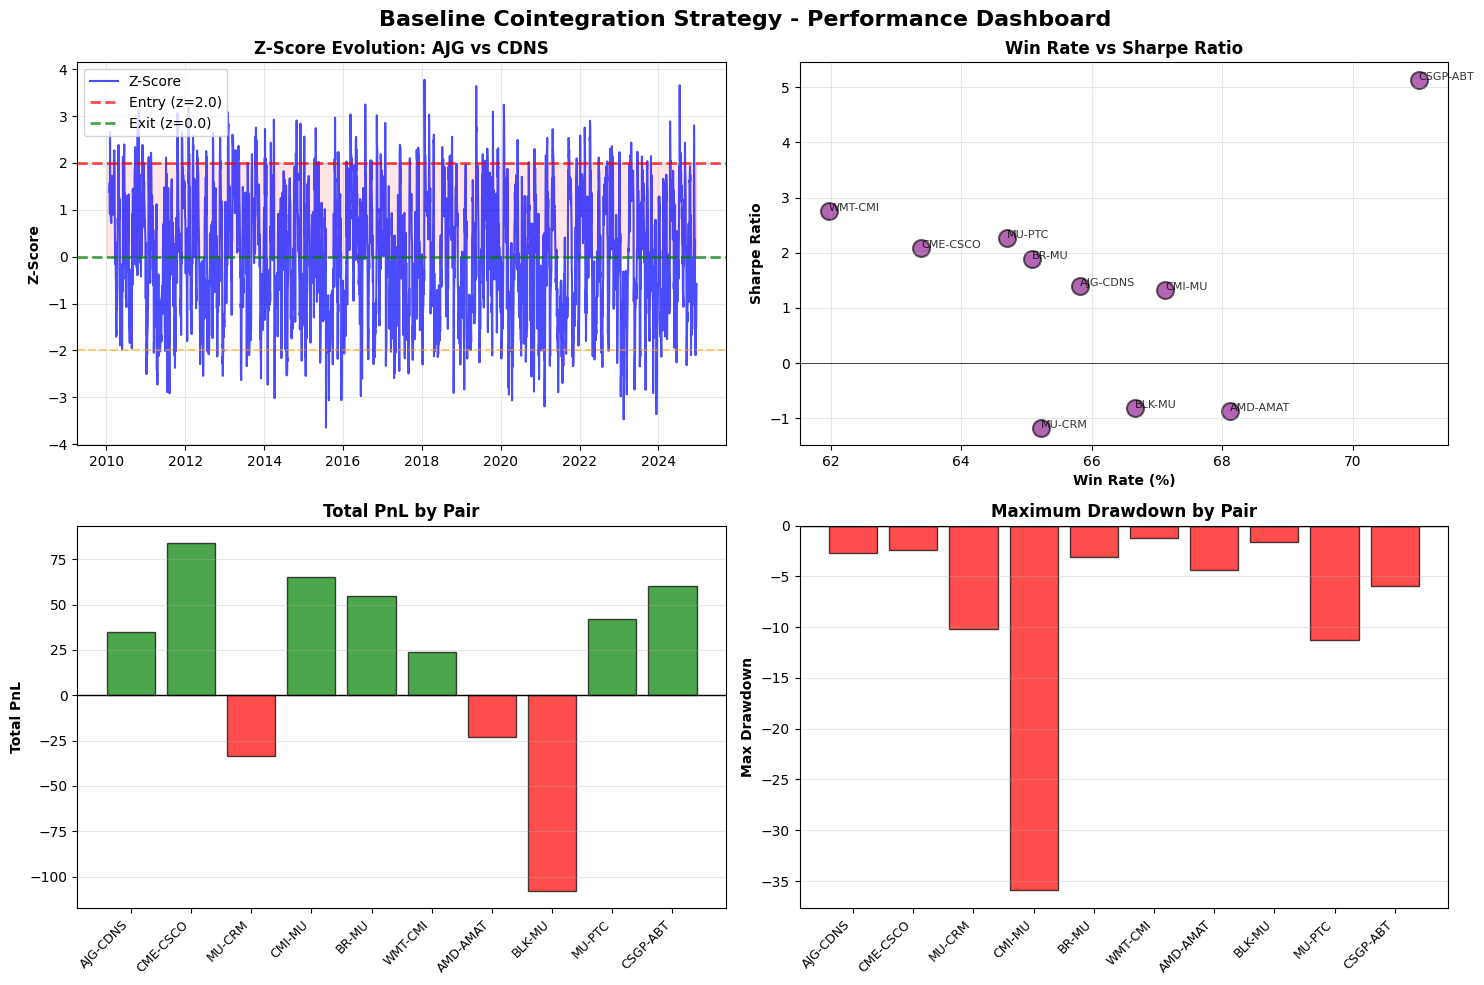

Visualization saved to: ./dataset/baseline_strategy_visualization.png


In [11]:
import matplotlib.pyplot as plt

# Create comprehensive visualization
fig, axes = plt.subplots(2, 2, figsize=(15, 10))
fig.suptitle(
    "Baseline Cointegration Strategy - Performance Dashboard",
    fontsize=16,
    fontweight="bold",
)

# 1. Z-score for first pair
if len(spread_metrics) > 0:
    first_pair = list(spread_metrics.keys())[0]
    ticker1, ticker2 = first_pair
    metrics = spread_metrics[first_pair]

    ax1 = axes[0, 0]
    ax1.plot(
        metrics["zscore"].index,
        metrics["zscore"].values,
        label="Z-Score",
        color="blue",
        linewidth=1.5,
        alpha=0.7,
    )
    ax1.axhline(
        y=2.0,
        color="red",
        linestyle="--",
        label="Entry (z=2.0)",
        alpha=0.7,
        linewidth=2,
    )
    ax1.axhline(
        y=0.0,
        color="green",
        linestyle="--",
        label="Exit (z=0.0)",
        alpha=0.7,
        linewidth=2,
    )
    ax1.axhline(y=-2.0, color="orange", linestyle="--", alpha=0.5)
    ax1.fill_between(metrics["zscore"].index, 0, 2, alpha=0.1, color="red")
    ax1.set_ylabel("Z-Score", fontweight="bold")
    ax1.set_title(f"Z-Score Evolution: {ticker1} vs {ticker2}", fontweight="bold")
    ax1.legend(loc="upper left")
    ax1.grid(True, alpha=0.3)

# 2. Win rate vs Sharpe ratio
ax2 = axes[0, 1]
if len(baseline_metrics) > 0:
    win_rates = [m["win_rate"] * 100 for m in baseline_metrics.values()]
    sharpe_ratios = [m["sharpe_ratio"] for m in baseline_metrics.values()]
    pair_names = [f"{p[0]}-{p[1]}" for p in baseline_metrics.keys()]

    ax2.scatter(
        win_rates,
        sharpe_ratios,
        s=150,
        alpha=0.6,
        color="purple",
        edgecolors="black",
        linewidth=1.5,
    )
    for i, name in enumerate(pair_names):
        ax2.annotate(name, (win_rates[i], sharpe_ratios[i]), fontsize=8, alpha=0.8)
    ax2.set_xlabel("Win Rate (%)", fontweight="bold")
    ax2.set_ylabel("Sharpe Ratio", fontweight="bold")
    ax2.set_title("Win Rate vs Sharpe Ratio", fontweight="bold")
    ax2.grid(True, alpha=0.3)
    ax2.axhline(y=0, color="black", linestyle="-", linewidth=0.5)

# 3. PnL distribution
ax3 = axes[1, 0]
if len(baseline_metrics) > 0:
    total_pnls = [m["total_pnl"] for m in baseline_metrics.values()]
    colors_pnl = ["green" if x > 0 else "red" for x in total_pnls]
    pair_names = [f"{p[0]}-{p[1]}" for p in baseline_metrics.keys()]
    ax3.bar(
        range(len(total_pnls)),
        total_pnls,
        color=colors_pnl,
        alpha=0.7,
        edgecolor="black",
    )
    ax3.set_xticks(range(len(pair_names)))
    ax3.set_xticklabels(pair_names, rotation=45, ha="right", fontsize=9)
    ax3.set_ylabel("Total PnL", fontweight="bold")
    ax3.set_title("Total PnL by Pair", fontweight="bold")
    ax3.axhline(y=0, color="black", linestyle="-", linewidth=1)
    ax3.grid(True, alpha=0.3, axis="y")

# 4. Max Drawdown
ax4 = axes[1, 1]
if len(baseline_metrics) > 0:
    max_drawdowns = [m["max_drawdown"] for m in baseline_metrics.values()]
    colors_dd = ["red" if x < -0.1 else "orange" for x in max_drawdowns]
    ax4.bar(
        range(len(max_drawdowns)),
        max_drawdowns,
        color=colors_dd,
        alpha=0.7,
        edgecolor="black",
    )
    ax4.set_xticks(range(len(pair_names)))
    ax4.set_xticklabels(pair_names, rotation=45, ha="right", fontsize=9)
    ax4.set_ylabel("Max Drawdown", fontweight="bold")
    ax4.set_title("Maximum Drawdown by Pair", fontweight="bold")
    ax4.axhline(y=0, color="black", linestyle="-", linewidth=1)
    ax4.grid(True, alpha=0.3, axis="y")

plt.tight_layout()
plt.savefig(
    "./dataset/baseline_strategy_visualization.png", dpi=150, bbox_inches="tight"
)
plt.show()

print("Visualization saved to: ./dataset/baseline_strategy_visualization.png")

## Stage 3.5: Detailed Trade Analysis


In [12]:
for pair, trades_df in list(backtest_results.items())[:3]:  # Show first 3 pairs
    print(f"\n{pair[0]} ↔ {pair[1]}")

    trades_df_display = trades_df.copy()
    trades_df_display["entry_date"] = trades_df_display["entry_date"].dt.strftime(
        "%Y-%m-%d"
    )
    trades_df_display["exit_date"] = trades_df_display["exit_date"].dt.strftime(
        "%Y-%m-%d"
    )
    trades_df_display["pnl"] = trades_df_display["pnl"].round(4)
    trades_df_display["entry_zscore"] = trades_df_display["entry_zscore"].round(3)
    trades_df_display["exit_zscore"] = trades_df_display["exit_zscore"].round(3)

    print(f"Total trades: {len(trades_df)}")
    print(f"\nFirst 10 trades:")
    display(trades_df_display.head(10))

    # Statistics
    metrics = baseline_metrics[pair]
    print(f"\nTrade Statistics:")
    print(
        f"  Winning trades: {metrics['winning_trades']} ({metrics['win_rate']*100:.1f}%)"
    )
    print(f"  Losing trades: {metrics['losing_trades']}")
    print(f"  Avg winning trade: {metrics['avg_win']:.4f}")
    print(f"  Avg losing trade: {metrics['avg_loss']:.4f}")
    print(f"  Total PnL: {metrics['total_pnl']:.4f}")
    print(f"  Sharpe Ratio: {metrics['sharpe_ratio']:.3f}")
    print(f"  Max Drawdown: {metrics['max_drawdown']:.3f}")

print("Stage 3 (Baseline Cointegration Strategy) COMPLETED")
print("\nSummary of Completed Tasks:")
print("  - Cointegration tests (Engle-Granger)")
print("  - Spread and z-score computation")
print("  - Mean-reversion trading rule (entry: z > 2, exit: z < 0)")
print("  - Backtest engine with PnL calculation")
print("  - Performance metrics: Sharpe ratio, drawdowns, win rate")
print("  - Results saved to ./dataset/baseline_strategy_results.csv")
print("  - Visualization saved to ./dataset/baseline_strategy_visualization.png")


AJG ↔ CDNS
Total trades: 79

First 10 trades:


,entry_date,entry_zscore,exit_date,exit_zscore,pnl,days_held
0,2010-02-03,2.659,2010-03-22,-0.151,-0.7040,47
1,2010-04-20,2.015,2010-05-06,-1.888,1.0381,16
2,2010-06-03,2.133,2010-06-04,-0.393,0.8967,1
3,2010-06-14,2.199,2010-06-29,-0.264,0.3399,15
4,2010-09-24,2.337,2010-10-08,-0.226,0.4878,14
5,2010-10-18,2.873,2010-11-12,-0.137,-0.4591,25
6,2010-12-01,2.385,2010-12-29,-0.083,-0.2434,28
7,2011-01-27,2.126,2011-02-03,-0.220,0.8482,7
8,2011-02-18,2.218,2011-03-09,-0.383,0.6910,19
9,2011-07-07,2.116,2011-07-15,-1.050,0.5897,8



Trade Statistics:
  Winning trades: 52 (65.8%)
  Losing trades: 27
  Avg winning trade: 2.6336
  Avg losing trade: -3.7806
  Total PnL: 34.8723
  Sharpe Ratio: 1.394
  Max Drawdown: -2.692

CME ↔ CSCO
Total trades: 71

First 10 trades:


,entry_date,entry_zscore,exit_date,exit_zscore,pnl,days_held
0,2010-04-02,2.011,2010-04-07,-0.501,3.3990,5
1,2010-05-06,3.133,2010-06-09,-0.164,-6.3385,34
2,2010-06-29,2.036,2010-07-07,-2.150,5.8665,8
3,2010-08-26,2.048,2010-09-16,-0.596,2.1649,21
4,2010-11-11,3.732,2010-12-27,-0.874,-8.2449,46
5,2011-02-10,2.944,2011-04-06,-0.276,-4.0410,55
6,2011-08-09,2.065,2011-08-11,-2.700,10.2855,2
7,2012-02-02,2.903,2012-03-06,-0.284,-3.2391,33
8,2012-05-10,3.660,2012-06-14,-0.129,-1.7358,35
9,2012-07-12,2.496,2012-07-18,-0.309,2.6719,6



Trade Statistics:
  Winning trades: 45 (63.4%)
  Losing trades: 26
  Avg winning trade: 5.7651
  Avg losing trade: -6.7508
  Total PnL: 83.9082
  Sharpe Ratio: 2.093
  Max Drawdown: -2.413

MU ↔ CRM
Total trades: 69

First 10 trades:


,entry_date,entry_zscore,exit_date,exit_zscore,pnl,days_held
0,2010-03-17,2.031,2010-04-06,-0.878,0.3439,20
1,2010-09-28,2.057,2010-10-26,-0.102,-0.8122,28
2,2010-12-17,2.069,2011-01-06,-0.182,0.1993,20
3,2011-01-12,3.040,2011-02-22,-1.033,-1.9870,41
4,2011-03-01,2.158,2011-03-09,-0.762,0.6117,8
5,2011-08-17,2.056,2011-08-31,-0.733,0.4031,14
6,2011-11-16,3.028,2011-12-05,-0.470,0.4482,19
7,2011-12-22,2.523,2012-01-19,-0.092,-0.2907,28
8,2012-05-10,3.213,2012-05-18,-1.007,1.5039,8
9,2012-07-09,2.009,2012-07-18,-0.921,0.9496,9



Trade Statistics:
  Winning trades: 45 (65.2%)
  Losing trades: 24
  Avg winning trade: 2.3837
  Avg losing trade: -5.8754
  Total PnL: -33.7427
  Sharpe Ratio: -1.167
  Max Drawdown: -10.158
Stage 3 (Baseline Cointegration Strategy) COMPLETED

Summary of Completed Tasks:
  - Cointegration tests (Engle-Granger)
  - Spread and z-score computation
  - Mean-reversion trading rule (entry: z > 2, exit: z < 0)
  - Backtest engine with PnL calculation
  - Performance metrics: Sharpe ratio, drawdowns, win rate
  - Results saved to ./dataset/baseline_strategy_results.csv
  - Visualization saved to ./dataset/baseline_strategy_visualization.png
